# Stability Analysis

The Jacobian matrix **J** at a cell state **x** characterises local dynamics:



$$J_{ij}(x) = \frac{\partial \dot{x}_i}{\partial x_j} = W_{ij} \cdot \sigma'(x_j) - \gamma_i \delta_{ij}$$



Key stability indicators:

- **Trace(J)** < 0 → contracting (stabilising) dynamics

- **Leading Re(λ)** < 0 → local attractor; > 0 → local repeller / saddle

- **Rotational part** → oscillatory tendency



Topics covered:

1. Compute Jacobian matrices

2. Jacobian summary statistics on UMAP

3. Eigenvalue spectra per cluster

4. Rotational dynamics

5. Element-wise Jacobian analysis

## Setup

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import scHopfield as sch
 
DATA_PATH    = './scratch/Data/'
DATASET_FILE = 'hematopoiesis.h5ad'
MODEL_FILE   = 'model.h5sch'

CLUSTER_KEY  = 'cell_type'
SPLICED_KEY  = 'M_t'

CELL_TYPE_ORDER = ['Meg', 'Ery', 'MEP-like', 'HSC', 'GMP-like', 'Mon', 'Bas', 'Neu']

adata = sc.read_h5ad(DATA_PATH + DATASET_FILE)
adata = sch.tl.load_model(adata, MODEL_FILE)
print(adata)

colors = dict(zip(CELL_TYPE_ORDER, adata.uns['cell_type_colors']))
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')


/tmp/ipykernel_1221845/3765484981.py:17: UserWarning: adata has 1956 genes but the model was trained on 1728.  A subsetted copy is being returned; the original adata is NOT modified.  Reassign the return value:
    adata = sch.tl.load_model(adata, filename)
  adata = sch.tl.load_model(adata, MODEL_FILE)


Model loaded from 'model.h5sch'  |  clusters=['Bas', 'Ery', 'GMP-like', 'HSC', 'MEP-like', 'Meg', 'Mon', 'Neu', 'all']  |  genes=1728
AnnData object with n_obs × n_vars = 1947 × 1728
    obs: 'batch', 'time', 'cell_type', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'new_Size_Factor', 'initial_new_cell_size', 'total_Size_Factor', 'initial_total_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size', 'ntr', 'cell_cycle_phase', 'leiden', 'control_point_pca', 'inlier_prob_pca', 'obs_vf_angle_pca', 'pca_ddhodge_div', 'pca_ddhodge_potential', 'acceleration_pca', 'curvature_pca', 'n_counts', 'mt_frac', 'jacobian_det_pca', 'manual_selection', 'divergence_pca', 'curv_leiden', 'curv_louvain', 'SPI1->GATA1_jacobian', 'jacobian', 'umap_ori_leiden', 'umap_ori_louvain', 'umap_ddhodge_div', 'umap_ddhodge_potential', 'curl_umap', 'divergence_umap', 'acceleration_umap', 'control_point_umap_ori', '

## 4.1 Compute Jacobian Matrices



**Warning**: This is memory-intensive for large datasets.

Save immediately after computation.

In [34]:
sch.tl.compute_jacobians(
    adata,
    spliced_key=SPLICED_KEY,
    cluster_key=CLUSTER_KEY,
    compute_eigenvectors=False,   # Set True only if eigenvectors are needed
    device=device
)

print("Jacobian eigenvalues stored in adata.obsm['jacobian_eigenvalues']")


Computing Jacobians for cluster Mon


100%|██████████| 423/423 [00:10<00:00, 40.81it/s]


Computing Jacobians for cluster Meg


100%|██████████| 154/154 [00:03<00:00, 43.17it/s]


Computing Jacobians for cluster MEP-like


...

Computing Jacobians for cluster HSC


100%|██████████| 309/309 [00:07<00:00, 40.43it/s]


Computing Jacobians for cluster Neu


100%|██████████| 32/32 [00:00<00:00, 41.02it/s]

Jacobian eigenvalues stored in adata.obsm['jacobian_eigenvalues']


In [ ]:
# Save to disk to avoid re-computation
# sch.tl.save_jacobians(
#     adata,
#     filename='jacobian_eigenvalues.h5',
#     cluster_key=CLUSTER_KEY,
#     compression='gzip'
# )
# print("Jacobians saved to disk.")


In [ ]:
# Load from disk later (if previously saved):
# sch.tl.load_jacobians(
#     adata,
#     filename='jacobian_eigenvalues.h5',
#     load_eigenvectors=False
# )
# sch.tl.compute_jacobian_stats(adata, store_in_obs=True)


## 4.2 Jacobian Statistics



Extracts per-cell scalar summaries from eigenvalue arrays and stores them in

`adata.obs`.

In [35]:
sch.tl.compute_jacobian_stats(
    adata,
    filename=None,     # use adata.obsm if None, or pass a filename to load from disk
    store_in_obs=True
)

stats_cols = [
    'jacobian_eig1_real', 'jacobian_eig1_imag',
    'jacobian_positive_evals', 'jacobian_negative_evals',
    'jacobian_trace'
]
print("Jacobian statistics per cell:")
adata.obs[stats_cols].describe()


Jacobian statistics per cell:


,jacobian_eig1_real,jacobian_eig1_imag,jacobian_positive_evals,jacobian_negative_evals,jacobian_trace
count,1947.000000,1947.0,1947.000000,1947.000000,1947.000000
mean,-0.068015,0.0,17.364664,1710.635336,-296.985982
std,0.031078,0.0,3.917776,3.917776,2.714663
min,-0.646356,0.0,4.000000,1698.000000,-306.789470
25%,-0.064679,0.0,15.000000,1708.000000,-298.732645
50%,-0.064679,0.0,17.000000,1711.000000,-297.255203
75%,-0.064679,0.0,20.000000,1713.000000,-295.487251
max,-0.005080,0.0,30.000000,1724.000000,-287.853683


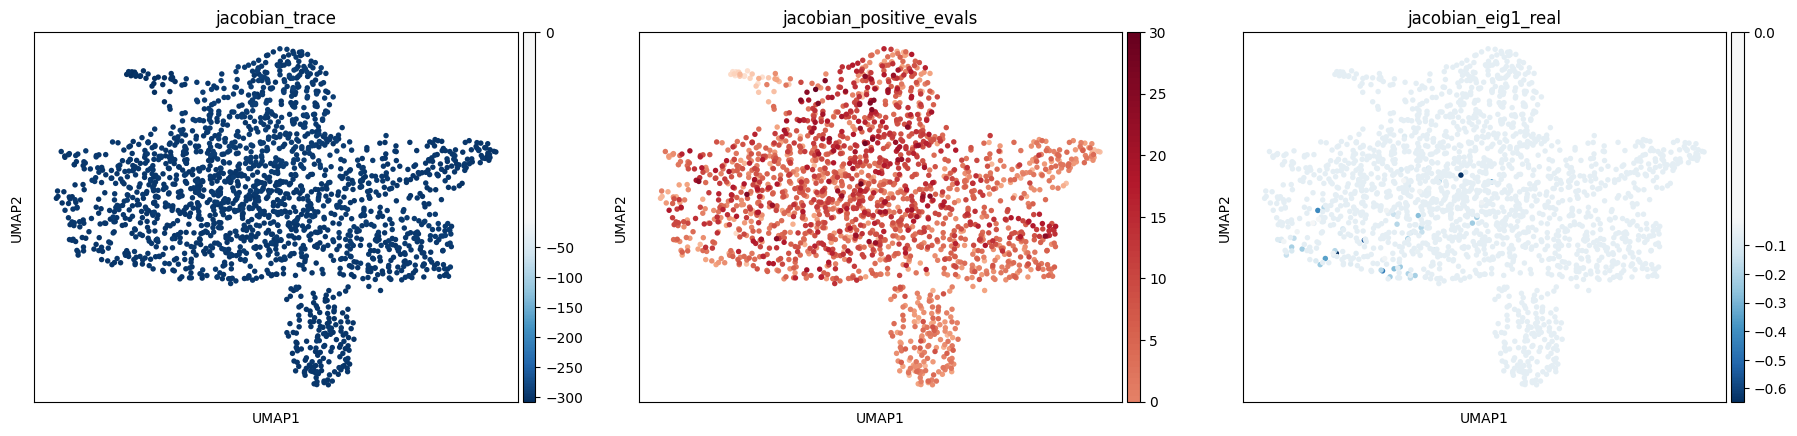

In [36]:
# Visualise on UMAP
sc.pl.umap(
    adata,
    color=['jacobian_trace', 'jacobian_positive_evals', 'jacobian_eig1_real'],
    ncols=3,
    cmap='RdBu_r',
    vcenter=0
)


In [37]:
# Summary per cluster
summary = adata.obs.groupby(CLUSTER_KEY).agg({
    'jacobian_positive_evals': ['mean', 'std'],
    'jacobian_negative_evals': ['mean', 'std'],
    'jacobian_trace':          ['mean', 'std'],
})
print("\nJacobian Statistics Summary:")
summary.round(3)



Jacobian Statistics Summary:


jacobian_positive_evals        jacobian_negative_evals         \
                             mean    std                    mean    std   
cell_type                                                                 
Bas                        15.492  3.010                1712.508  3.010   
Ery                        17.350  3.096                1710.650  3.096   
GMP-like                   16.832  3.218                1711.168  3.218   
HSC                        17.317  3.969                1710.683  3.969   
MEP-like                   17.998  3.471                1710.002  3.471   
Meg                        14.649  2.138                1713.351  2.138   
Mon                        19.390  3.950                1708.610  3.950   
Neu                         8.219  3.405                1719.781  3.405   

          jacobian_trace         
                    mean    std  
cell_type                        
Bas             -297.896  1.907  
Ery             -296.432  2.021  
GMP-like        -297.408  1.934  
HSC             -297.905  1.739  
MEP-like        -297.345  1.852  
Meg             -298.837  1.759  
Mon             -294.455  2.827  
Neu             -304.415  2.780

## 4.3 Eigenvalue Spectra

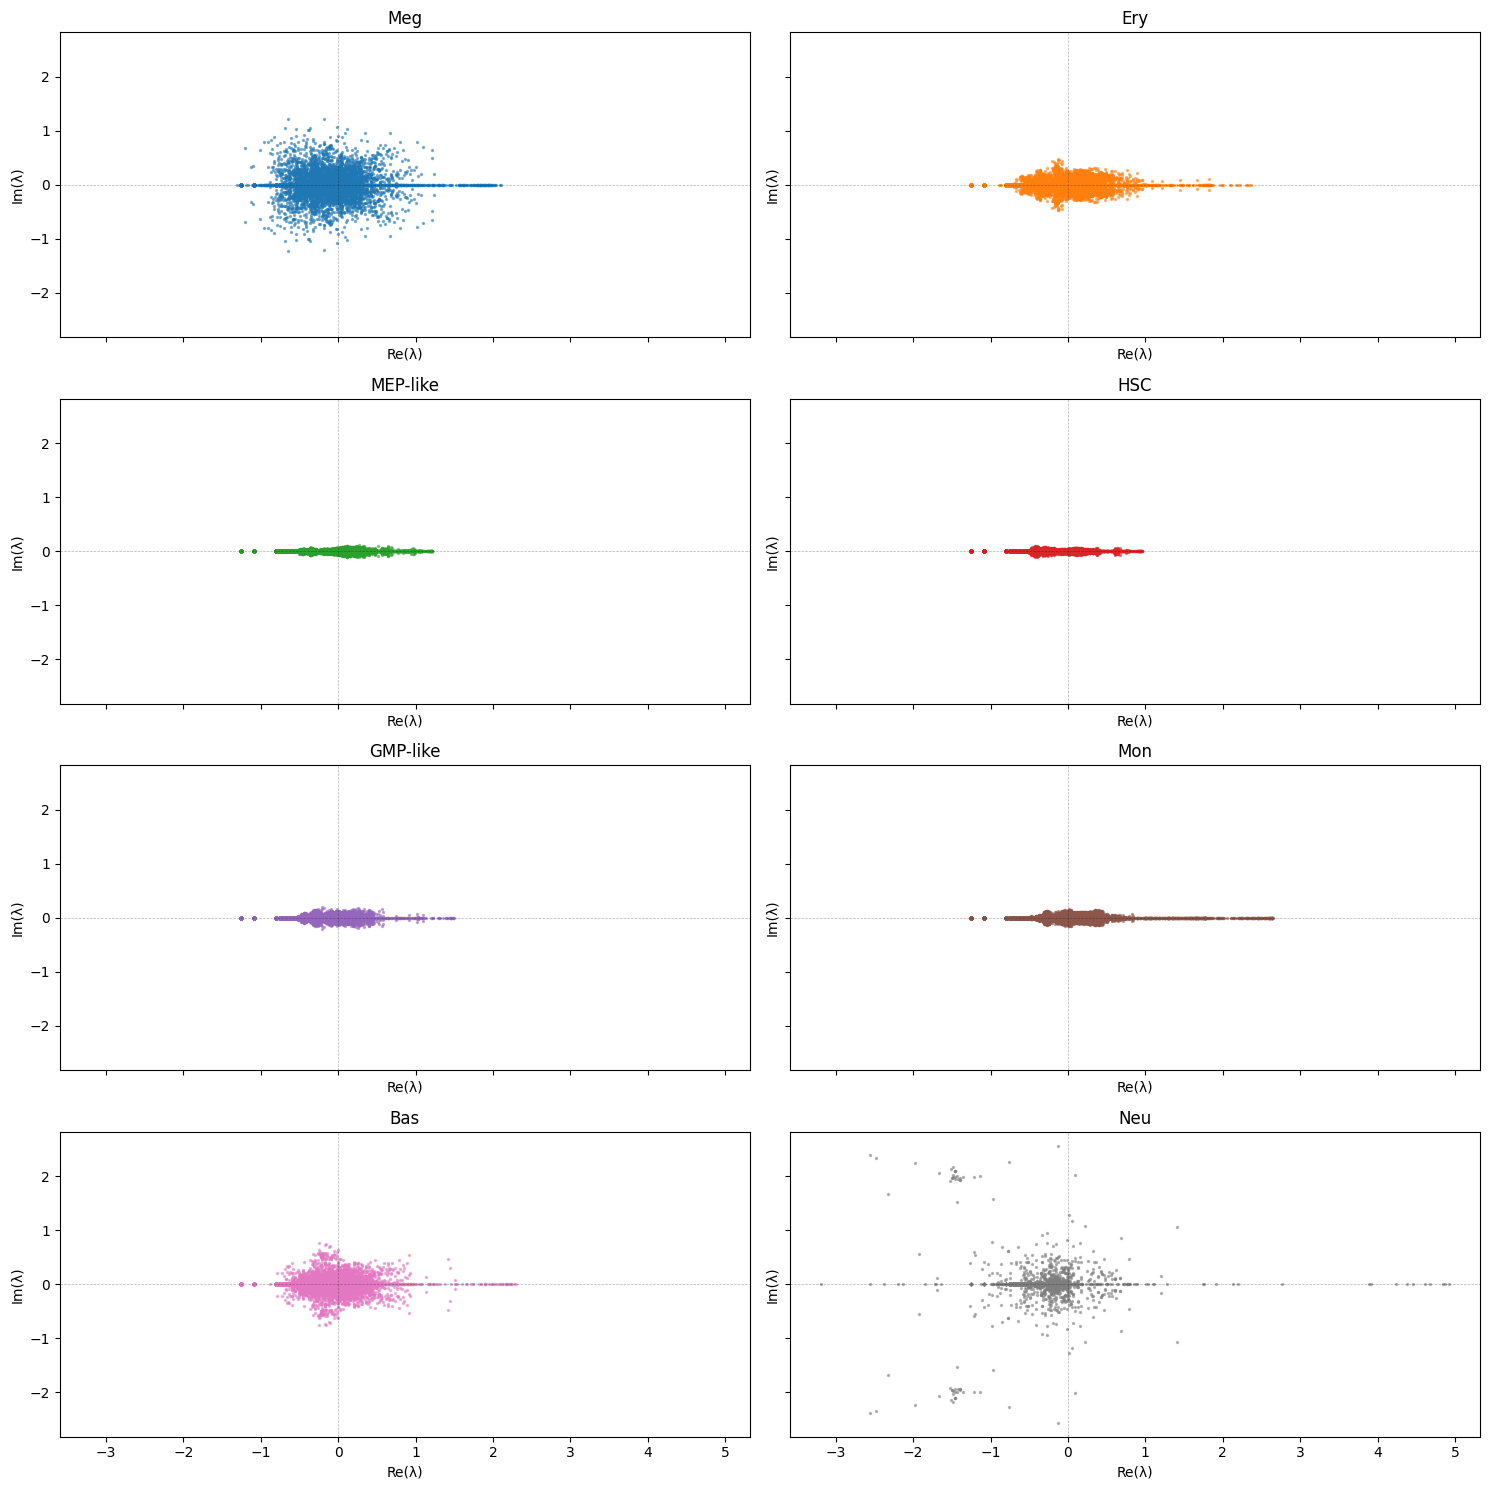

In [38]:
# Eigenvalue spectrum in the complex plane (per cluster)
fig = sch.pl.plot_jacobian_eigenvalue_spectrum(
    adata,
    cluster_key=CLUSTER_KEY,
    order=CELL_TYPE_ORDER,
    colors=colors,
    figsize=(15, 15)
)
plt.show()


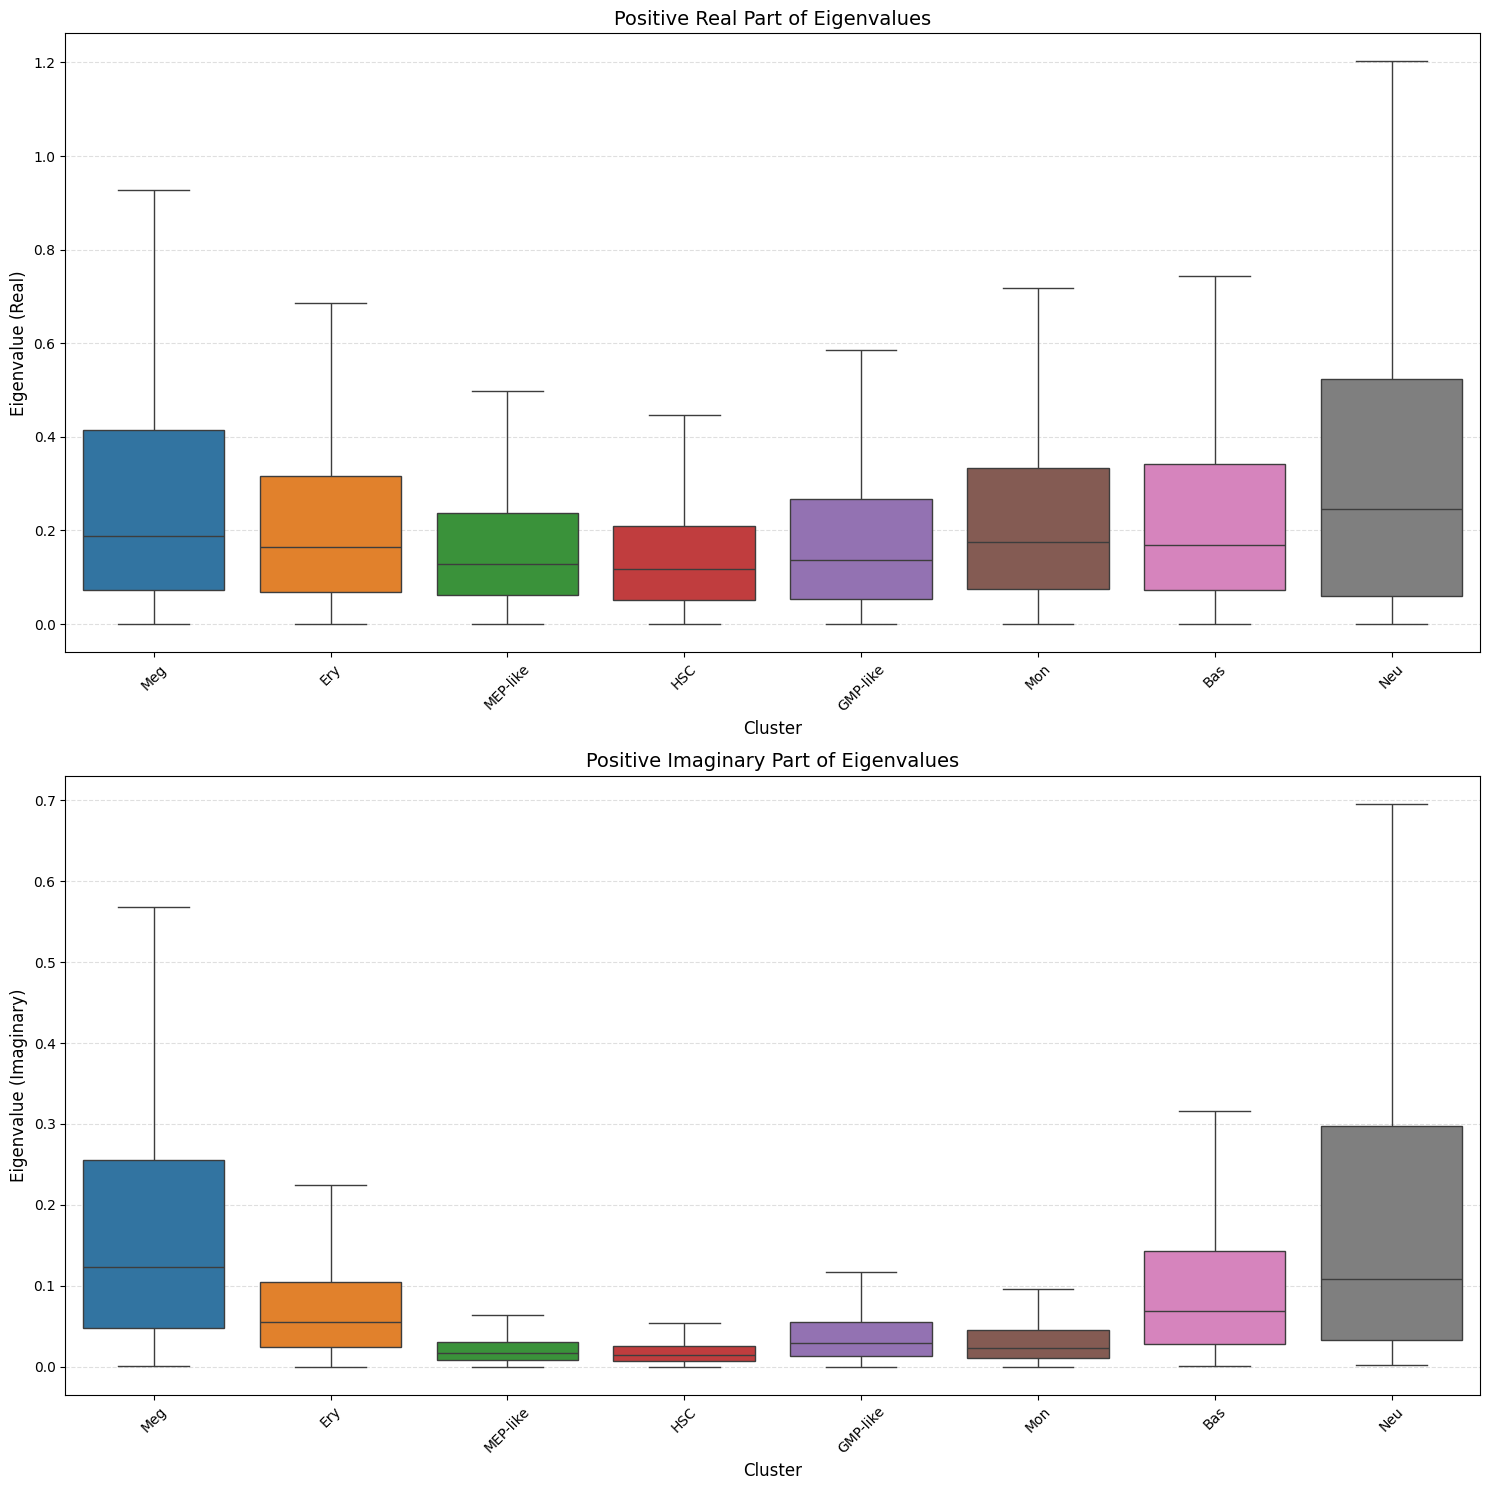

In [39]:
# Boxplots of positive eigenvalue counts
fig = sch.pl.plot_jacobian_eigenvalue_boxplots(
    adata,
    cluster_key=CLUSTER_KEY,
    order=CELL_TYPE_ORDER,
    colors=colors,
    figsize=(15, 15)
)
plt.show()


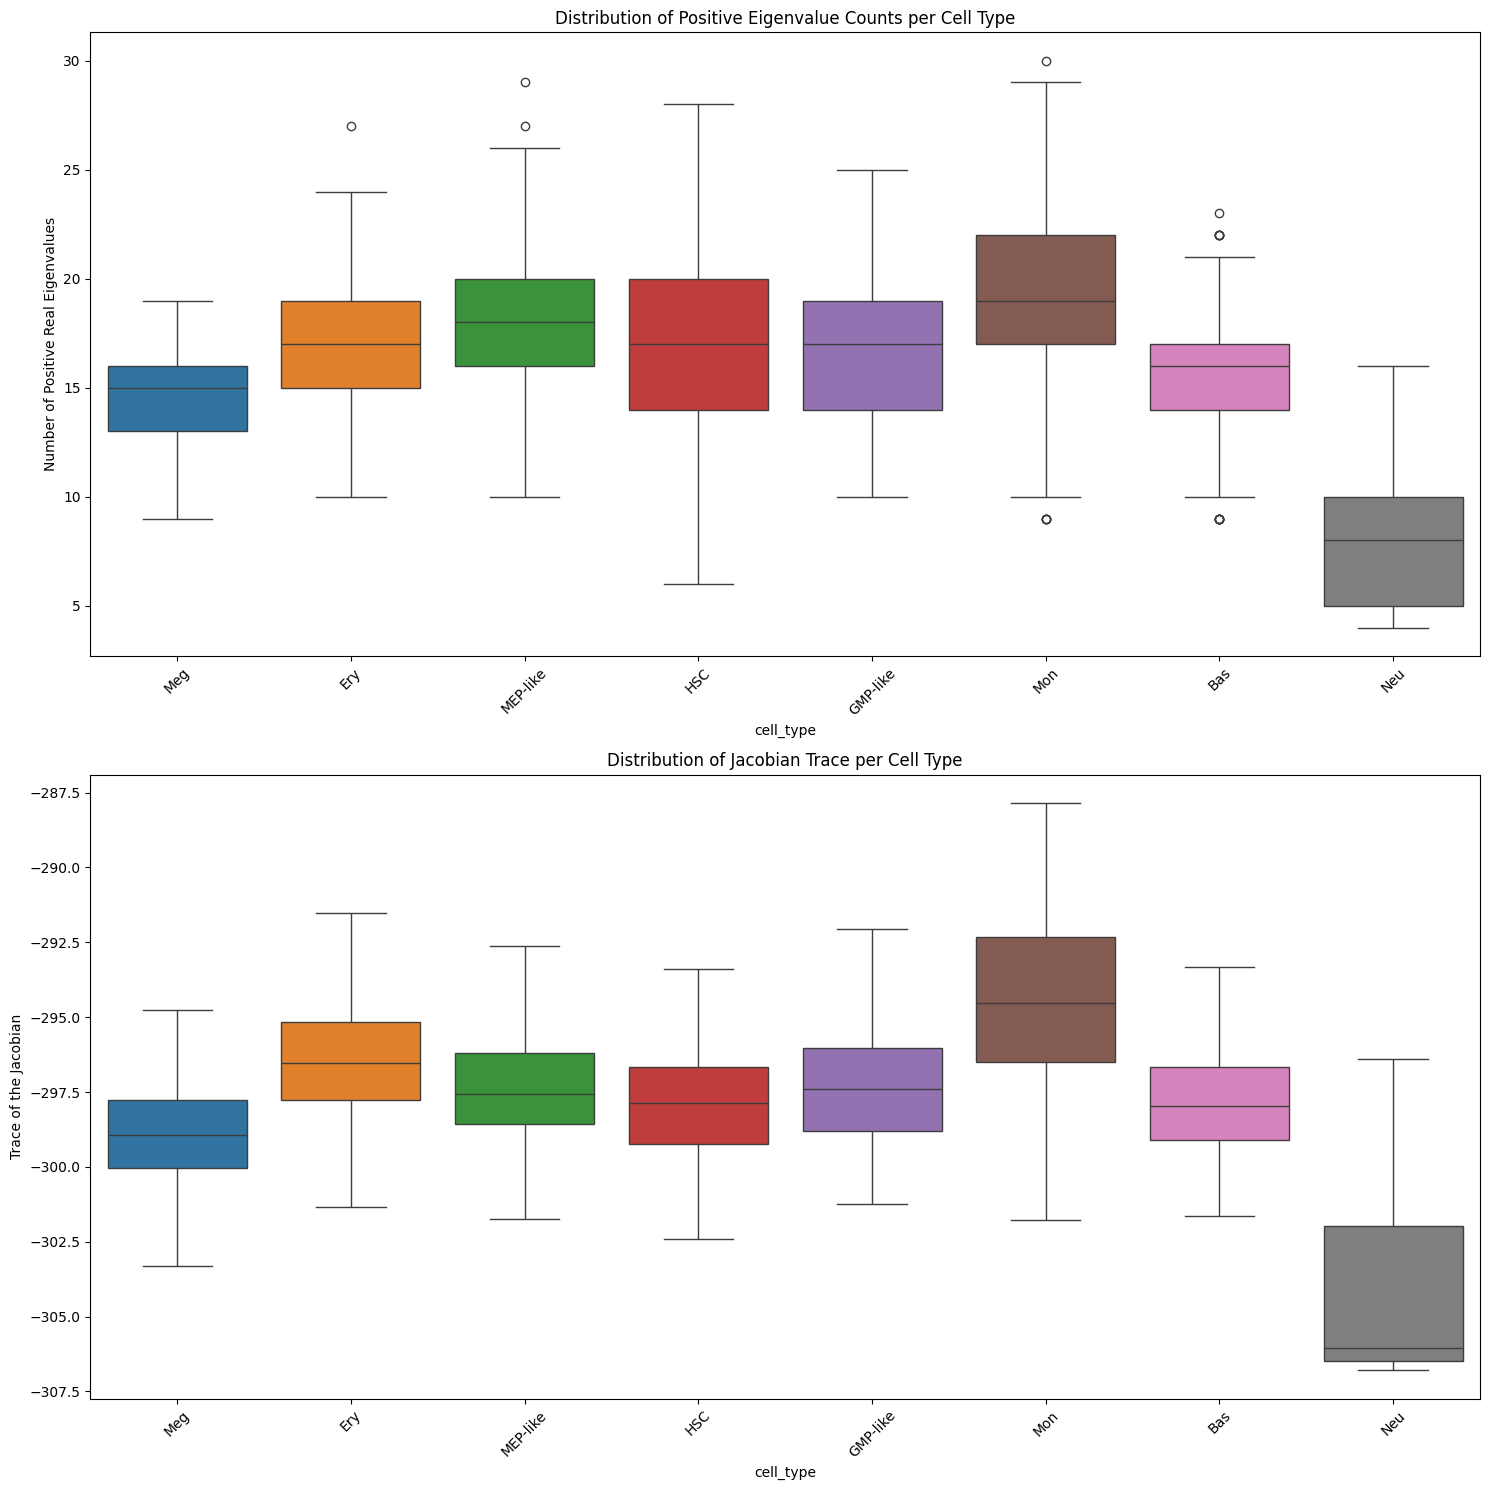

In [40]:
# Jacobian summary statistics as boxplots
fig = sch.pl.plot_jacobian_stats_boxplots(
    adata,
    cluster_key=CLUSTER_KEY,
    order=CELL_TYPE_ORDER,
    colors=colors,
    figsize=(15, 15)
)
plt.show()


In [41]:
# Print extreme eigenvalues per cluster
print("Extreme eigenvalues per cluster:")
eigenvalues = adata.obsm['jacobian_eigenvalues']
for cluster in CELL_TYPE_ORDER:
    mask = (adata.obs[CLUSTER_KEY] == cluster).values
    evals_cluster = eigenvalues[mask]
    max_real = evals_cluster.real.max()
    min_real = evals_cluster.real.min()
    print(f"  {cluster:15s} | Max Re(λ): {max_real:8.3f} | Min Re(λ): {min_real:8.3f}")


Extreme eigenvalues per cluster:
  Meg             | Max Re(λ):    2.100 | Min Re(λ):   -1.309
  Ery             | Max Re(λ):    2.363 | Min Re(λ):   -1.257
  MEP-like        | Max Re(λ):    1.216 | Min Re(λ):   -1.257
  HSC             | Max Re(λ):    0.957 | Min Re(λ):   -1.257
  GMP-like        | Max Re(λ):    1.492 | Min Re(λ):   -1.257
  Mon             | Max Re(λ):    2.645 | Min Re(λ):   -1.257
  Bas             | Max Re(λ):    2.294 | Min Re(λ):   -1.257
  Neu             | Max Re(λ):    4.918 | Min Re(λ):   -3.191


## 4.4 Rotational Dynamics



The antisymmetric part of J generates rotation in gene-expression phase space.

High rotational magnitude → oscillatory / spiralling dynamics near the cell state.

In [42]:
sch.tl.compute_rotational_part(
    adata,
    spliced_key=SPLICED_KEY,
    cluster_key=CLUSTER_KEY,
    device=device
)

print("Rotational magnitude stored in adata.obs['jacobian_rotational']")


Computing rotational part for cluster Mon


Cluster Mon: 100%|██████████| 423/423 [00:00<00:00, 1968.56it/s]


Computing rotational part for cluster Meg


Cluster Meg: 100%|██████████| 154/154 [00:00<00:00, 4001.06it/s]


Computing rotational part for cluster MEP-like


...

Computing rotational part for cluster HSC


Cluster HSC: 100%|██████████| 309/309 [00:00<00:00, 4231.57it/s]


Computing rotational part for cluster Neu


Cluster Neu: 100%|██████████| 32/32 [00:00<00:00, 4046.36it/s]

Rotational magnitude stored in adata.obs['jacobian_rotational']


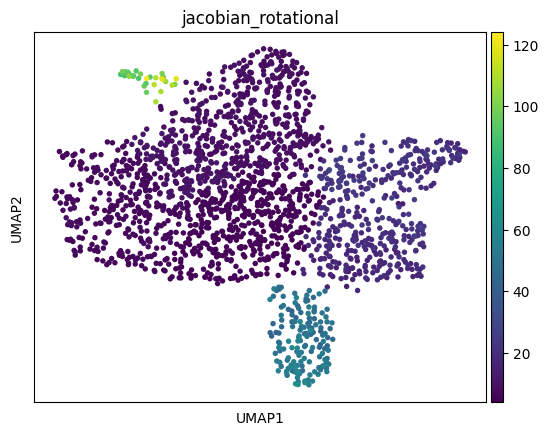

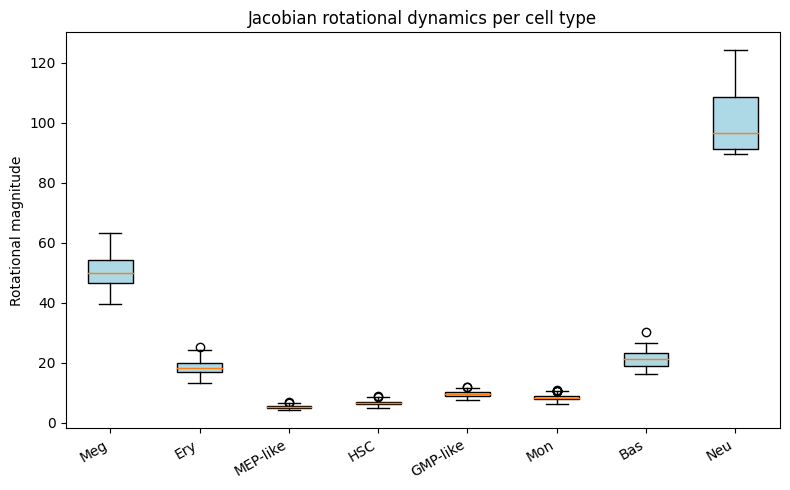

In [43]:
# Visualise rotational magnitude per cluster
sc.pl.umap(adata, color='jacobian_rotational', cmap='viridis')

# Boxplots
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5), tight_layout=True)
data = [adata.obs.loc[adata.obs[CLUSTER_KEY] == ct, 'jacobian_rotational'].values
        for ct in CELL_TYPE_ORDER]
ax.boxplot(data, labels=CELL_TYPE_ORDER, patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
ax.set_xticklabels(CELL_TYPE_ORDER, rotation=30, ha='right')
ax.set_ylabel('Rotational magnitude')
ax.set_title('Jacobian rotational dynamics per cell type')
plt.show()


## 4.5 Element-wise Jacobian Analysis



Compute specific partial derivatives ∂ẋᵢ/∂xⱼ for biologically motivated

gene pairs, and visualise them on the UMAP.

In [44]:
gene_pairs = [
    ('FLI1',  'KLF1'),  ('KLF1',  'FLI1'),
    ('FLI1',  'FLI1'),  ('KLF1',  'KLF1'),
    ('GATA1', 'GATA2'), ('GATA2', 'GATA1'),
    ('GATA1', 'KLF1'),  ('KLF1',  'GATA1'),
    ('GATA1', 'FLI1'),  ('FLI1',  'GATA1'),
    ('CEBPA', 'RUNX1'), ('RUNX1', 'CEBPA'),
    ('CEBPA', 'GATA2'), ('GATA2', 'CEBPA'),
    ('GATA2', 'RUNX1'), ('RUNX1', 'GATA2'),
    ('GATA2', 'GATA2'), ('RUNX1', 'RUNX1'),
]

sch.tl.compute_jacobian_elements(
    adata,
    gene_pairs=gene_pairs,
    spliced_key=SPLICED_KEY,
    cluster_key=CLUSTER_KEY,
    device=device,
    store_in_obs=True
)

print("Jacobian elements stored in adata.obs with names like: jacobian_df_GATA1_dx_GATA2")


Computing Jacobian elements for cluster Mon


Cluster Mon: 100%|██████████| 423/423 [00:01<00:00, 418.46it/s]


Computing Jacobian elements for cluster Meg


Cluster Meg: 100%|██████████| 154/154 [00:00<00:00, 479.46it/s]


Computing Jacobian elements for cluster MEP-like


...

Computing Jacobian elements for cluster HSC


Cluster HSC: 100%|██████████| 309/309 [00:00<00:00, 434.37it/s]


Computing Jacobian elements for cluster Neu


Cluster Neu: 100%|██████████| 32/32 [00:00<00:00, 493.67it/s]

Jacobian elements stored in adata.obs with names like: jacobian_df_GATA1_dx_GATA2


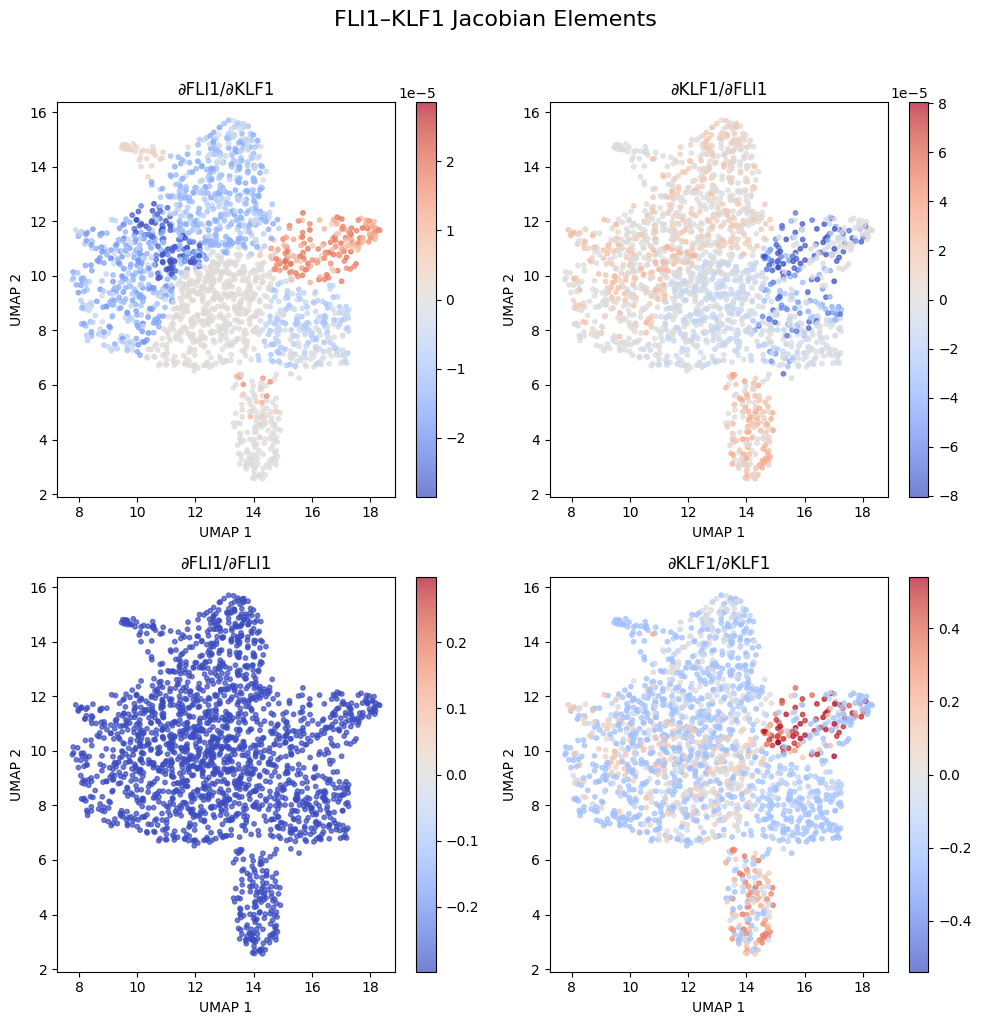

In [45]:
# FLI1–KLF1 mutual regulation
fig = sch.pl.plot_jacobian_element_grid(
    adata,
    gene_pairs=[('FLI1', 'KLF1'), ('KLF1', 'FLI1'),
                ('FLI1', 'FLI1'), ('KLF1', 'KLF1')],
    ncols=2,
    figsize=(10, 10),
    s=10,
    alpha=0.7
)
plt.suptitle('FLI1–KLF1 Jacobian Elements', fontsize=16, y=1.02)
plt.show()


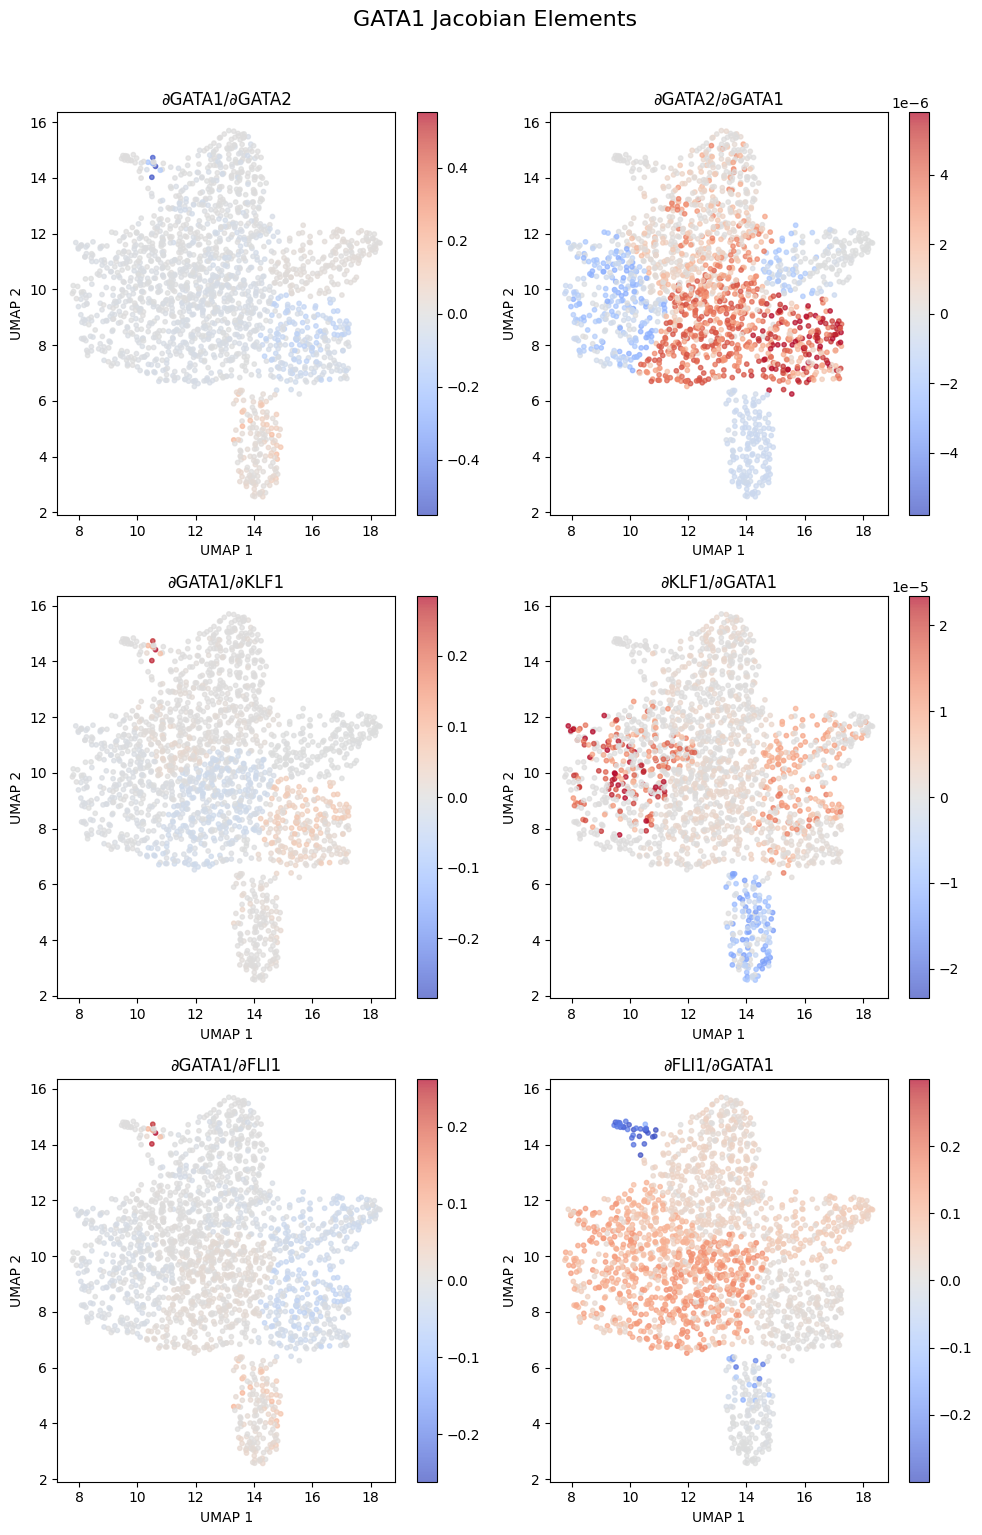

In [46]:
# GATA1 regulon
fig = sch.pl.plot_jacobian_element_grid(
    adata,
    gene_pairs=[('GATA1', 'GATA2'), ('GATA2', 'GATA1'),
                ('GATA1', 'KLF1'),  ('KLF1',  'GATA1'),
                ('GATA1', 'FLI1'),  ('FLI1',  'GATA1')],
    ncols=2,
    figsize=(10, 15),
    s=10,
    alpha=0.7
)
plt.suptitle('GATA1 Jacobian Elements', fontsize=16, y=1.02)
plt.show()


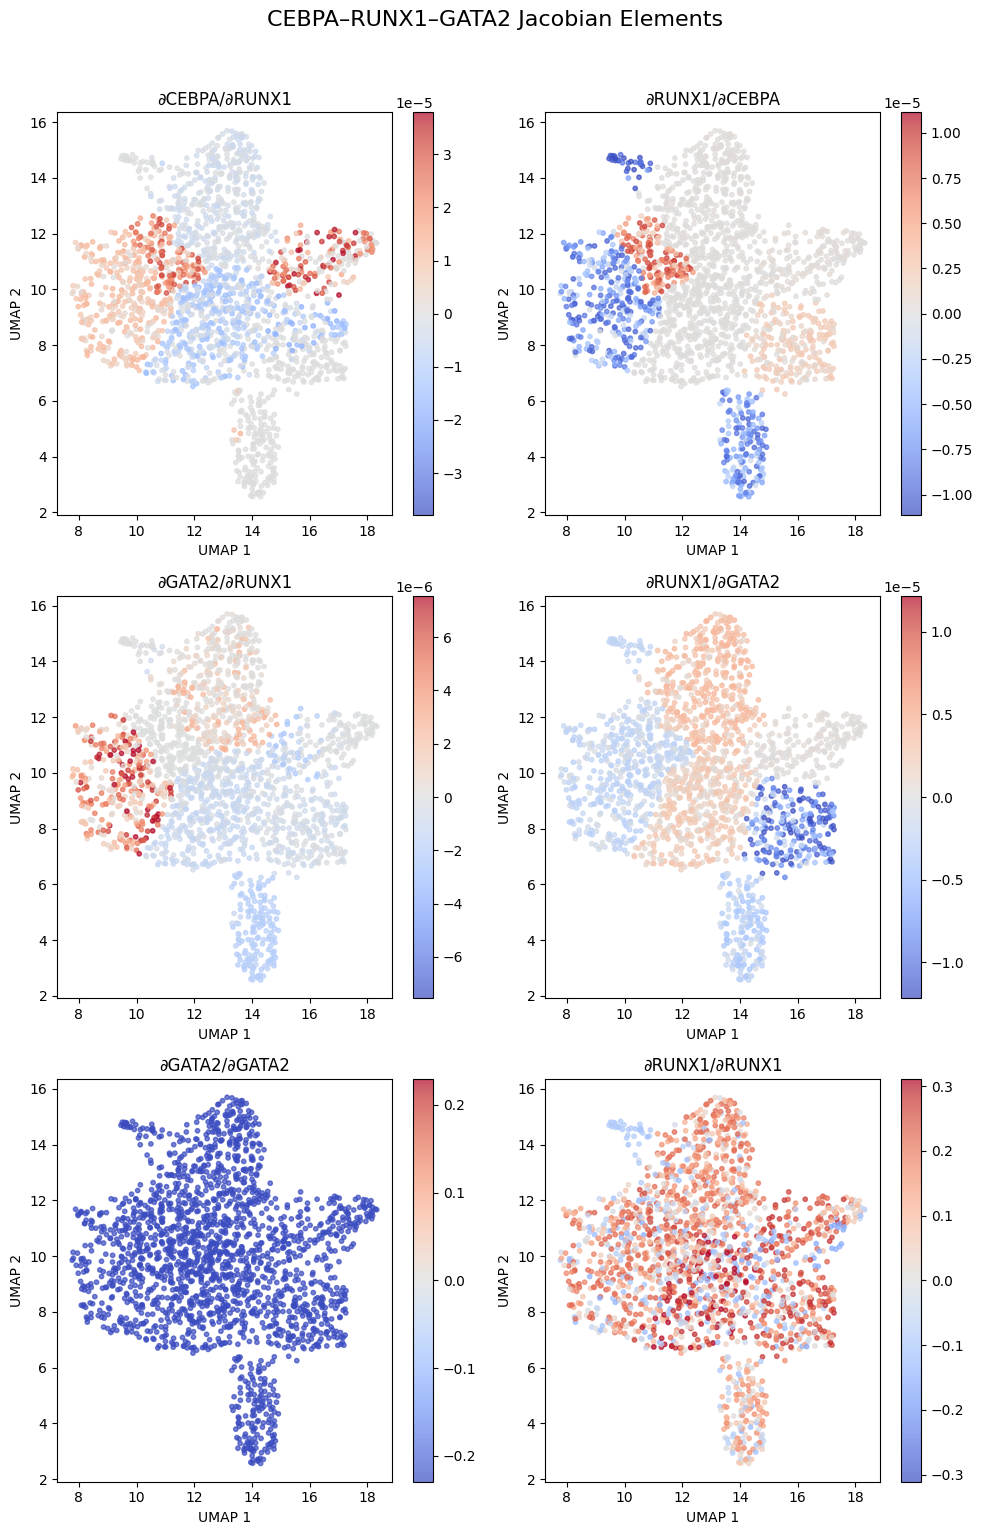

In [47]:
# CEBPA–RUNX1–GATA2 cross-regulation
fig = sch.pl.plot_jacobian_element_grid(
    adata,
    gene_pairs=[('CEBPA', 'RUNX1'), ('RUNX1', 'CEBPA'),
                ('GATA2', 'RUNX1'), ('RUNX1', 'GATA2'),
                ('GATA2', 'GATA2'), ('RUNX1', 'RUNX1')],
    ncols=2,
    figsize=(10, 15),
    s=10,
    alpha=0.7
)
plt.suptitle('CEBPA–RUNX1–GATA2 Jacobian Elements', fontsize=16, y=1.02)
plt.show()
